# 01 — SC4001 EEG Observation

This notebook implements only the real-EEG Observation stage. Its panel-by-panel organization follows the SBI Practical Guide Figure 10 assembly notebook: each scientific panel has an independent explanation, data preparation, plot call, immediate display, and SVG/PNG export. The pyloric-network science, panel lettering, and visual style are not copied.

**Scientific boundary:** no V7/V8a simulation, prior predictive run, NPE training, posterior diagnostic, or posterior predictive check is performed here. No fitting candidate is treated as a posterior sample.

## Workflow roadmap (not a scientific panel)

| Figure 10 concept | This project | Status |
|---|---|---|
| Simulator | 8-parameter cortical-thalamic simulator | Future notebook |
| Observation | SC4001 N3 EEG and observation summaries | **Completed here** |
| NPE ensemble | Five independently trained NPEs | Future notebook |
| Global diagnostics | Expected coverage / SBC | Future notebook |
| Local diagnostics | L-C2ST at observed EEG | Future notebook |
| Posterior predictive | Posterior predictive simulation | Future notebook |
| Posterior marginals | 8-parameter posterior marginals | Future notebook |

Unimplemented concepts remain explicit future work and do not receive blank or synthetic panels.

In [ ]:
from pathlib import Path # import the Path
import json # 
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "S4_sbi" / "src").is_dir():
    if (ROOT.parent / "src" / "sleep_sbi").is_dir():
        ROOT = ROOT.parent.parent
    else:
        raise RuntimeError("Run from the repository root or S4_sbi/notebooks")
SBI_SRC = ROOT / "S4_sbi" / "src"
if str(SBI_SRC) not in sys.path:
    sys.path.insert(0, str(SBI_SRC))

from sleep_sbi import (
    build_observation_bundle,
    load_observation_config,
    map_raw_stage,
    metric_classification_rows,
    plot_obs_a_recording_context,
    plot_obs_b_representative_eeg,
    plot_obs_c_psd,
    plot_obs_d_so_morphology,
    plot_obs_e_so_regularity,
    plot_obs_f_spindle_activity,
    plot_obs_g_pac,
    plot_obs_h_summary_qc,
    save_panel,
    write_observation_artifacts,
)

config = load_observation_config()
OUTPUT_ROOT = ROOT / config.artifact_output_dir
panel_records = {}
print(f"Python: {sys.version.split()[0]} | output: {config.artifact_output_dir}")

Python: 3.10.20 | output: outputs/observation_sc4001


## Load and verify the ObservationBundle

The ignored local `data/manifest.csv` resolves the SC4001 PSG and annotation EDF files. The bundle holds retained 30-second arrays in memory, but publication artifacts contain only aggregate summaries, QC metadata, and figures. `fooof==1.1.1` is required exactly; there is no silent fallback.

In [2]:
bundle = build_observation_bundle(config)
bundle.validate()
assert map_raw_stage("Sleep stage 3") == "N3"
assert map_raw_stage("Sleep stage 4") == "N3"
assert map_raw_stage("3") == "N3"  # regression guard for the legacy short-label bug

recording_metadata = pd.DataFrame(
    {
        "field": [
            "subject", "channel", "sampling rate", "unit", "reference",
            "recording duration", "epoch duration", "random seed", "FOOOF",
        ],
        "value": [
            bundle.subject_id, bundle.channel, f"{bundle.fs_hz:g} Hz", "uV",
            bundle.provenance["reference"],
            f"{bundle.provenance['recording_duration_s'] / 3600:.3f} h",
            f"{bundle.epoch_duration_s:g} s", bundle.provenance["random_seed"],
            bundle.provenance["fooof_version"],
        ],
    }
)
display(recording_metadata)
display(pd.DataFrame(bundle.diagnostics["annotation_table"]))
print("Warnings:")
for warning in bundle.warnings:
    print(" -", warning)

S4_sbi/src/sleep_sbi/observation.py:117: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


,field,value
0,subject,SC4001
1,channel,EEG Fpz-Cz
2,sampling rate,100 Hz
3,unit,uV
4,reference,bipolar derivation Fpz-Cz as recorded; no addi...
5,recording duration,22.083 h
6,epoch duration,30 s
7,random seed,20260723
8,FOOOF,1.1.1


,raw_label,aasm_label,annotation_events,duration_s,duration_epochs_30s,aligned_recording_epochs
0,Sleep stage 1,N1,24,1740.0,58,58
1,Sleep stage 2,N2,40,7500.0,250,250
2,Sleep stage 3,N3,48,3030.0,101,101
3,Sleep stage 4,N3,23,3570.0,119,119
4,Sleep stage ?,Unknown,1,6900.0,230,0
5,Sleep stage R,REM,6,3750.0,125,125
6,Sleep stage W,W,12,59910.0,1997,1997


Warnings:
 - hypnogram extends 6900.0s beyond the complete PSG epochs; alignment was clipped to the PSG


## Obs-a — Recording context and N3 selection

**Scientific question:** Where do the analyzed N3 epochs occur in the full recording, and how were raw annotations standardized?

**Input:** Full-night annotation alignment plus the N3 QC decisions.

**Method:** Native 30-second boundaries are retained. `Sleep stage 3`, `Sleep stage 4`, and short label `3` map to N3; each epoch is processed independently and discontinuous N3 epochs are never concatenated.

**Validity:** The hypnogram is clipped to complete PSG epochs. Retained and rejected N3 sets must be disjoint and exhaustive.

**Plot:** Full-night stages, N3 positions, and actual raw annotation event counts.

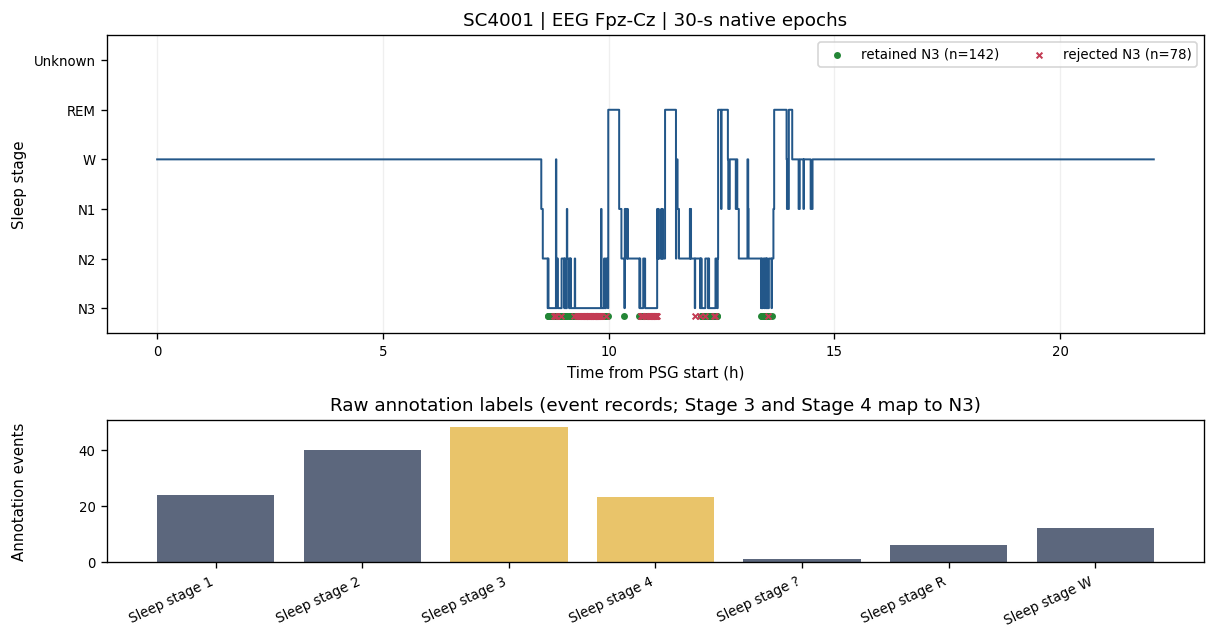

**Interpretation:** SC4001 contains 220 N3 epochs; 142 pass QC and 78 are rejected. Stage 3 and Stage 4 both contribute to N3, while the time axis preserves their original night positions.

**Artifact:** `panels/obs_a_recording_context.svg` and `.png`.

In [3]:
fig, obs_a_data = plot_obs_a_recording_context(bundle)
display(fig)
panel_records["Obs-a"] = save_panel(
    fig, bundle, "Obs-a", obs_a_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(Markdown(
    f"**Interpretation:** SC4001 contains {obs_a_data['n3_epoch_count']} N3 epochs; "
    f"{obs_a_data['retained_epoch_count']} pass QC and {obs_a_data['rejected_epoch_count']} are rejected. "
    "Stage 3 and Stage 4 both contribute to N3, while the time axis preserves their original night positions.\n\n"
    "**Artifact:** `panels/obs_a_recording_context.svg` and `.png`."
))

## Obs-b — Representative 30-second N3 EEG

**Scientific question:** What does retained N3 EEG look like across the observed amplitude range?

**Input:** QC-retained SC4001 Fpz-Cz epochs.

**Method:** Representatives are fixed peak-to-peak quantiles (0.15 to 0.85), with the recorded seed used only for deterministic tie filling.

**Validity:** Every trace is exactly one native 30-second epoch and is explicitly labeled retained; no samples cross an epoch boundary.

**Plot:** Independent raw EEG traces with epoch index, channel, time, and microvolt units.

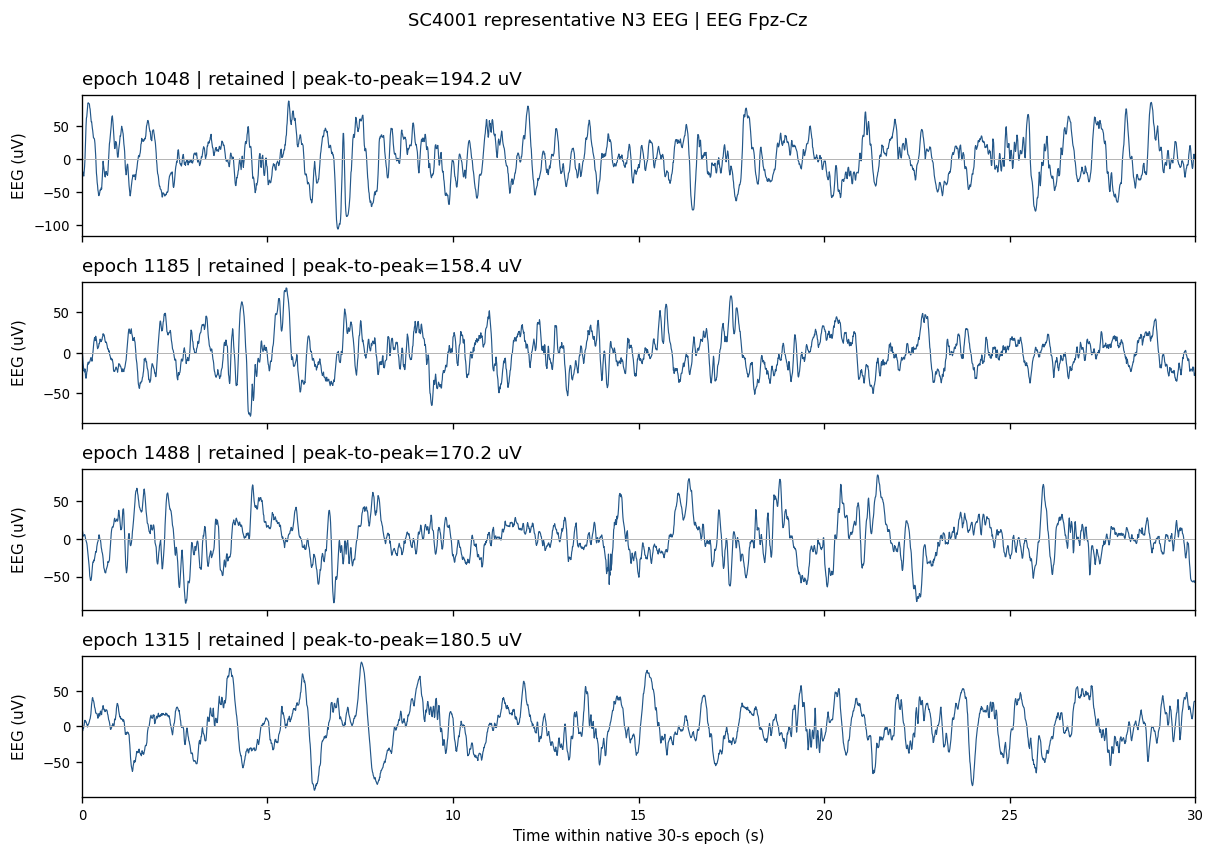

,epoch_index,selection_metric,peak_to_peak_uv,status
0,1048,peak_to_peak_uv,194.203663,retained
1,1185,peak_to_peak_uv,158.382418,retained
2,1488,peak_to_peak_uv,170.197802,retained
3,1315,peak_to_peak_uv,180.512821,retained


**Interpretation:** The deterministic representatives show substantial within-N3 amplitude variation without hand selection. They are visual examples only; the complete retained set enters aggregate summaries.

**Artifact:** `panels/obs_b_representative_eeg.svg` and `.png`; no raw samples are serialized in panel metadata.

In [4]:
fig, obs_b_data = plot_obs_b_representative_eeg(bundle, n_epochs=4)
display(fig)
panel_records["Obs-b"] = save_panel(
    fig, bundle, "Obs-b", obs_b_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(pd.DataFrame(obs_b_data["selected_epochs"]))
display(Markdown(
    "**Interpretation:** The deterministic representatives show substantial within-N3 amplitude variation without hand selection. "
    "They are visual examples only; the complete retained set enters aggregate summaries.\n\n"
    "**Artifact:** `panels/obs_b_representative_eeg.svg` and `.png`; no raw samples are serialized in panel metadata."
))

## Obs-c — Epoch-level and aggregate PSD

**Scientific question:** What spectral structure and cross-epoch variability characterize retained N3 EEG?

**Input:** Per-epoch Welch PSDs from retained 30-second epochs.

**Method:** The primary result uses Hann windows because the current fitting target implementation uses Hann. Welch segments are 4 seconds with 1-second overlap, 0.25-Hz resolution, constant detrending, and arithmetic-mean epoch aggregation. Legacy prose mentioned Hamming, so Hamming is shown only as sensitivity analysis.

**Validity:** Welch is computed separately per epoch; all PSD arrays and normalized aggregates must be finite.

**Plot:** Single-epoch PSD, retained-epoch intervals, aggregate PSD, SO band/peak, and Hann-Hamming sensitivity.

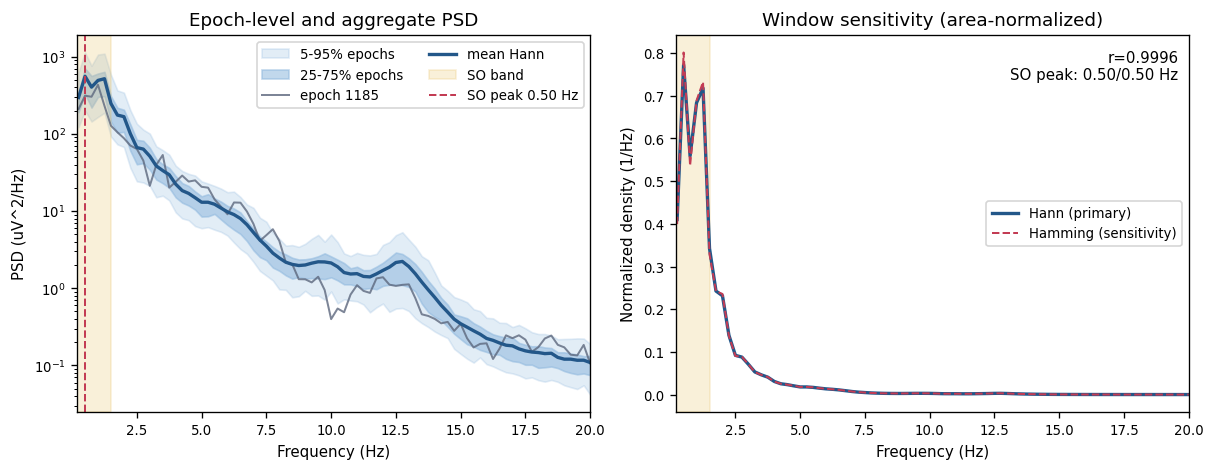

,so_peak_frequency_hz,relative_so_power,so_q
Hann primary,0.5,0.777428,4.869293
Hamming sensitivity,0.5,0.780901,5.041093


**Interpretation:** The Hann SO peak is 0.50 Hz. Hann and Hamming normalized spectra correlate at r=0.9996; the sensitivity window does not change the peak-frequency conclusion.

**Artifact:** `panels/obs_c_psd.svg` and `.png`.

In [5]:
fig, obs_c_data = plot_obs_c_psd(bundle)
display(fig)
panel_records["Obs-c"] = save_panel(
    fig, bundle, "Obs-c", obs_c_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(pd.DataFrame([obs_c_data["hann_statistics"], obs_c_data["hamming_statistics"]], index=["Hann primary", "Hamming sensitivity"]))
display(Markdown(
    f"**Interpretation:** The Hann SO peak is {obs_c_data['hann_statistics']['so_peak_frequency_hz']:.2f} Hz. "
    f"Hann and Hamming normalized spectra correlate at r={obs_c_data['hann_hamming_correlation']:.4f}; the sensitivity window does not change the peak-frequency conclusion.\n\n"
    "**Artifact:** `panels/obs_c_psd.svg` and `.png`."
))

## Obs-d — Slow-oscillation waveform morphology

**Scientific question:** What trough-centered morphology is supported by detected SO events?

**Input:** Per-epoch 0.2-4 Hz signals and AASM-style DOWN-to-UP half-wave events.

**Method:** Fourth-order Butterworth filtering and zero-phase filtering are applied independently per epoch. Events require the configured DOWN-to-UP duration and at least 75 uV half-wave amplitude; waveform snippets align to the negative peak.

**Validity:** Events without a complete ±1.25-second window inside their own epoch are excluded with reason `incomplete_boundary_window`; invalid detector epochs have an explicit mask and reason.

**Plot:** One detection example, individual valid waveforms, mean morphology, and variability.

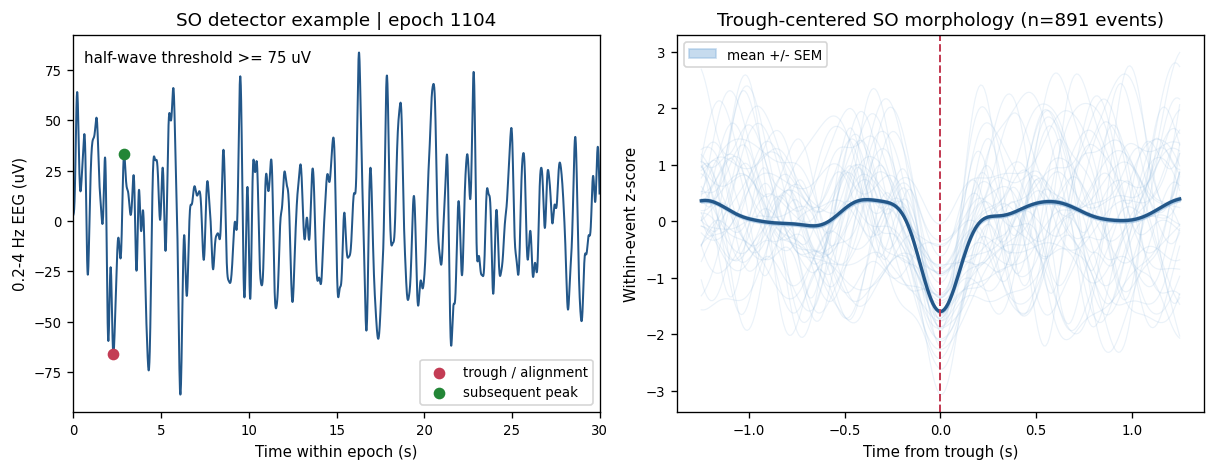

,panel_id,alignment,detector_parameters,detector_valid_epoch_count,waveform_valid_epoch_count,detector_invalid_epoch_count,valid_event_count,boundary_excluded_event_count,waveform_exclusion_reasons,example_epoch_index,valid_epoch_count
0,Obs-d,"negative SO peak (trough), within native epoch","{'filter': 'scipy.signal.butter+sosfiltfilt, p...",142,141,0,891,40,{'incomplete_boundary_window': 40},1104,141


**Interpretation:** 891 complete SO events support the trough-centered aggregate morphology. 40 boundary-near events are excluded rather than borrowing samples from another epoch.

**Artifact:** `panels/obs_d_so_morphology.svg` and `.png`.

In [6]:
fig, obs_d_data = plot_obs_d_so_morphology(bundle)
display(fig)
panel_records["Obs-d"] = save_panel(
    fig, bundle, "Obs-d", obs_d_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(pd.DataFrame([obs_d_data]))
display(Markdown(
    f"**Interpretation:** {obs_d_data['valid_event_count']} complete SO events support the trough-centered aggregate morphology. "
    f"{obs_d_data['boundary_excluded_event_count']} boundary-near events are excluded rather than borrowing samples from another epoch.\n\n"
    "**Artifact:** `panels/obs_d_so_morphology.svg` and `.png`."
))

## Obs-e — SO timing and regularity

**Scientific question:** How frequent and regular are detected SO events within native epochs?

**Input:** SO event times from each valid retained epoch.

**Method:** Inter-beat intervals (IBIs) are computed only between events in the same 30-second epoch. `IBI_CV = SD(IBI) / mean(IBI)`; lower values indicate more regular timing.

**Validity:** An epoch needs at least three SO events (two IBIs) for epoch-level IBI statistics. Invalid epochs return a false mask and a reason; NaNs are filtered explicitly before aggregation.

**Plot:** IBI distribution, event-rate variability, and valid epoch-level IBI_CV.

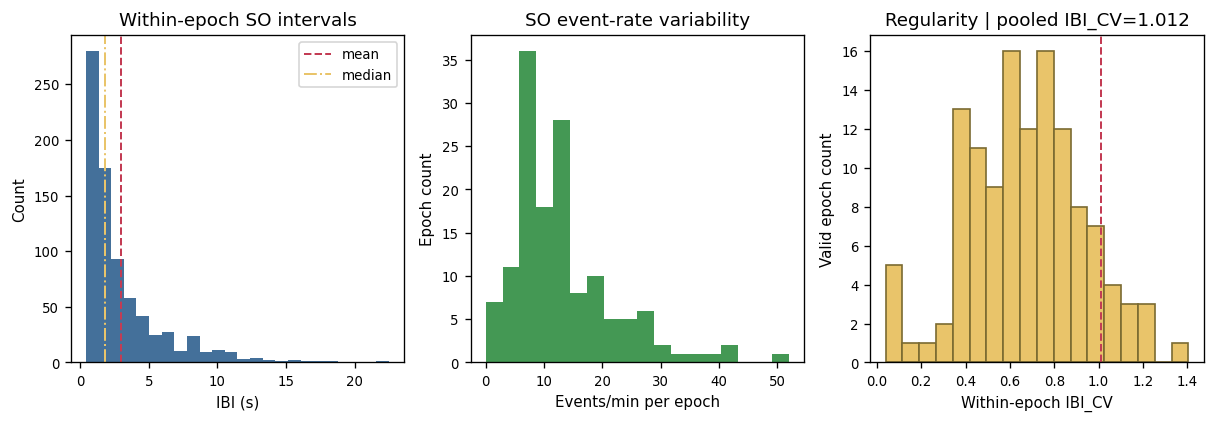

,panel_id,ibi_policy,so_event_rate_per_min,mean_ibi_s,median_ibi_s,ibi_cv,valid_ibi_count,valid_epoch_count,invalid_epoch_count,invalid_reason_counts
0,Obs-e,intervals computed only within each native 30-...,13.112676,2.931861,1.83,1.011715,779,124,18,{'fewer_than_three_so_events': 18}


**Interpretation:** The pooled within-epoch IBI_CV is 1.012, based on 779 intervals from 124 valid epochs. Intervals never bridge discontinuous N3 epochs, so this estimate describes local rather than overnight continuity.

**Artifact:** `panels/obs_e_so_regularity.svg` and `.png`.

In [7]:
fig, obs_e_data = plot_obs_e_so_regularity(bundle)
display(fig)
panel_records["Obs-e"] = save_panel(
    fig, bundle, "Obs-e", obs_e_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(pd.DataFrame([obs_e_data]))
display(Markdown(
    f"**Interpretation:** The pooled within-epoch IBI_CV is {obs_e_data['ibi_cv']:.3f}, based on {obs_e_data['valid_ibi_count']} intervals from {obs_e_data['valid_epoch_count']} valid epochs. "
    "Intervals never bridge discontinuous N3 epochs, so this estimate describes local rather than overnight continuity.\n\n"
    "**Artifact:** `panels/obs_e_so_regularity.svg` and `.png`."
))

## Obs-f — Observable spindle activity

**Scientific question:** What provisional spindle-like activity is observable on the real EEG channel?

**Input:** Retained SC4001 Fpz-Cz epochs.

**Method:** Each epoch is independently filtered at 11-15 Hz; a 0.2-second moving RMS envelope is thresholded at the per-epoch mean plus 1.5 SD, with configured duration and merge-gap rules.

**Validity:** Detector failures return a mask and reason. This real-EEG detector is `provisional` and a `held_out_ppc_candidate`; it is not V8a internal T13 and cannot inherit thalamic T8/T12 labels.

**Plot:** Band-passed signal, RMS threshold/event, duration distribution, and density variability.

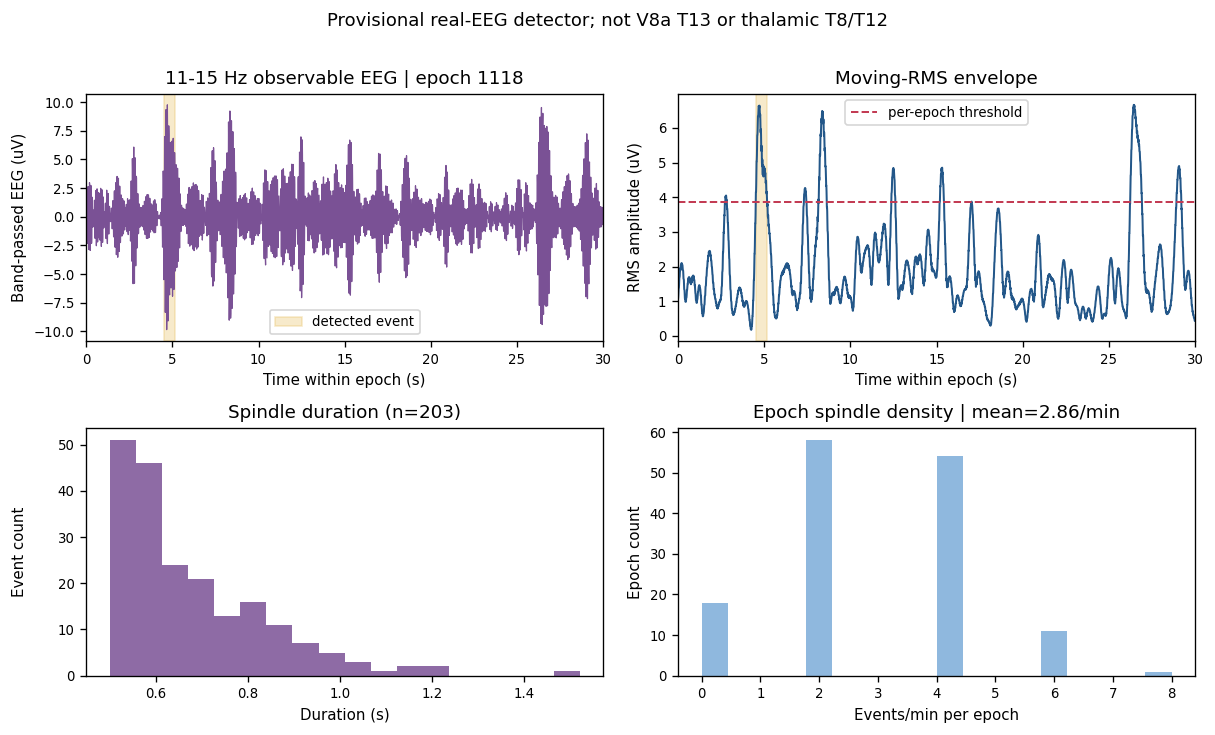

,panel_id,status,source,event_count,example_selection_rule,spindle_density_per_min,mean_duration_s,valid_epoch_count,invalid_epoch_count
0,Obs-f,provisional_held_out_ppc_candidate,SC4001/EEG Fpz-Cz,203,median peak envelope among events at least 2 s...,2.859155,0.676798,142,0


**Interpretation:** The provisional detector finds 203 events, corresponding to 2.859 events/min across retained N3. The result is descriptive and held out from the frozen inference summary until cross-signal calibration is resolved.

**Artifact:** `panels/obs_f_spindle_activity.svg` and `.png`.

In [8]:
fig, obs_f_data = plot_obs_f_spindle_activity(bundle)
display(fig)
panel_records["Obs-f"] = save_panel(
    fig, bundle, "Obs-f", obs_f_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
display(pd.DataFrame([{key: value for key, value in obs_f_data.items() if key not in {'detector_parameters', 'failure_reasons', 'warnings'}}]))
display(Markdown(
    f"**Interpretation:** The provisional detector finds {obs_f_data['event_count']} events, corresponding to {obs_f_data['spindle_density_per_min']:.3f} events/min across retained N3. "
    "The result is descriptive and held out from the frozen inference summary until cross-signal calibration is resolved.\n\n"
    "**Artifact:** `panels/obs_f_spindle_activity.svg` and `.png`."
))

## Obs-g — SO-spindle coupling / PAC

**Scientific question:** Is 10-14 Hz amplitude distributed non-uniformly over 0.5-1.5 Hz SO phase?

**Input:** Per-epoch SO phase and spindle-band Hilbert amplitude from retained EEG.

**Method:** Fourth-order zero-phase filters and Hilbert transforms are applied within each epoch, with 2 seconds trimmed from each edge. Tort normalized-KL MI uses 18 phase bins; phase-bin amplitude is aggregated over valid epochs.

**Validity:** Every bin needs sample support, and valid/invalid epoch counts are explicit. `T11_lag_ms` is a legacy misnomer and is never interpreted as lag; new fields are `pac_mi`, preferred phase rad/sin/cos, and `pac_up_down_ratio`.

**Plot:** SO phase, spindle amplitude, phase-amplitude distribution, preferred phase, and epoch-level MI support.

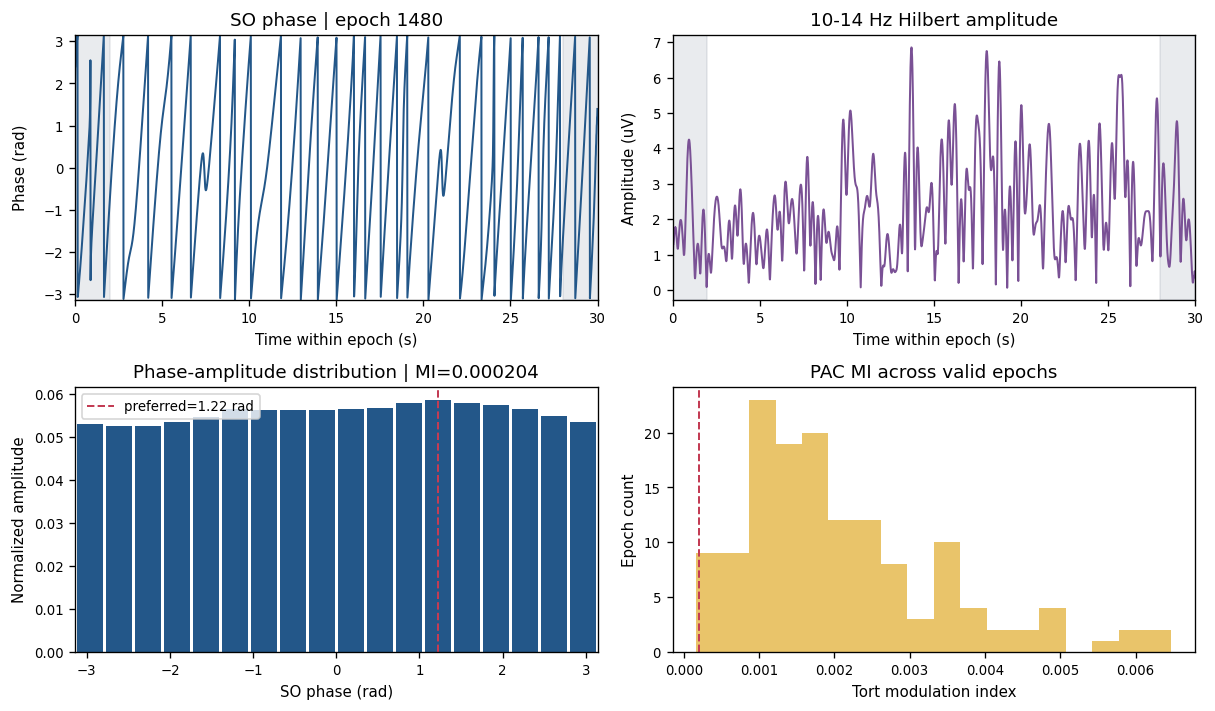

,pac_mi,pac_preferred_phase_rad,pac_preferred_phase_sin,pac_preferred_phase_cos,pac_up_down_ratio,valid_sample_count,valid_epoch_count,invalid_epoch_count
0,0.000204,1.22173,0.939693,0.34202,1.034337,369200,142,0


**Interpretation:** Observational PAC MI is 0.000204, with preferred phase 1.222 rad and 369200 supported samples. This weak single-channel coupling estimate remains a held-out PPC candidate rather than a frozen inference target.

**Artifact:** `panels/obs_g_pac.svg` and `.png`.

In [9]:
fig, obs_g_data = plot_obs_g_pac(bundle)
display(fig)
panel_records["Obs-g"] = save_panel(
    fig, bundle, "Obs-g", obs_g_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
pac_display = {key: value for key, value in obs_g_data.items() if key.startswith("pac_") or key.endswith("count")}
display(pd.DataFrame([pac_display]))
display(Markdown(
    f"**Interpretation:** Observational PAC MI is {obs_g_data['pac_mi']:.6f}, with preferred phase {obs_g_data['pac_preferred_phase_rad']:.3f} rad and {obs_g_data['valid_sample_count']} supported samples. "
    "This weak single-channel coupling estimate remains a held-out PPC candidate rather than a frozen inference target.\n\n"
    "**Artifact:** `panels/obs_g_pac.svg` and `.png`."
))

## Obs-h — QC and Observation summary table

**Scientific question:** What data support and validity metadata accompany the final Observation summaries?

**Input:** Bundle QC records, detector validity, per-epoch diagnostics, and structured summaries.

**Method:** Counts are reconciled exactly; invalid values are excluded explicitly. Every summary records field name, value, unit, band, algorithm, aggregation, valid epoch count, validity, intended role, and warnings.

**Validity:** `retained + rejected = N3` is mandatory. Intended roles are limited to `inference_summary_candidate`, `mechanism_diagnostic`, and `held_out_ppc_candidate`; simulator-only T8/T12/T13 are classified without fabricated EEG values.

**Plot:** Epoch accounting, rejection reasons, cross-epoch distributions, and the final summary table.

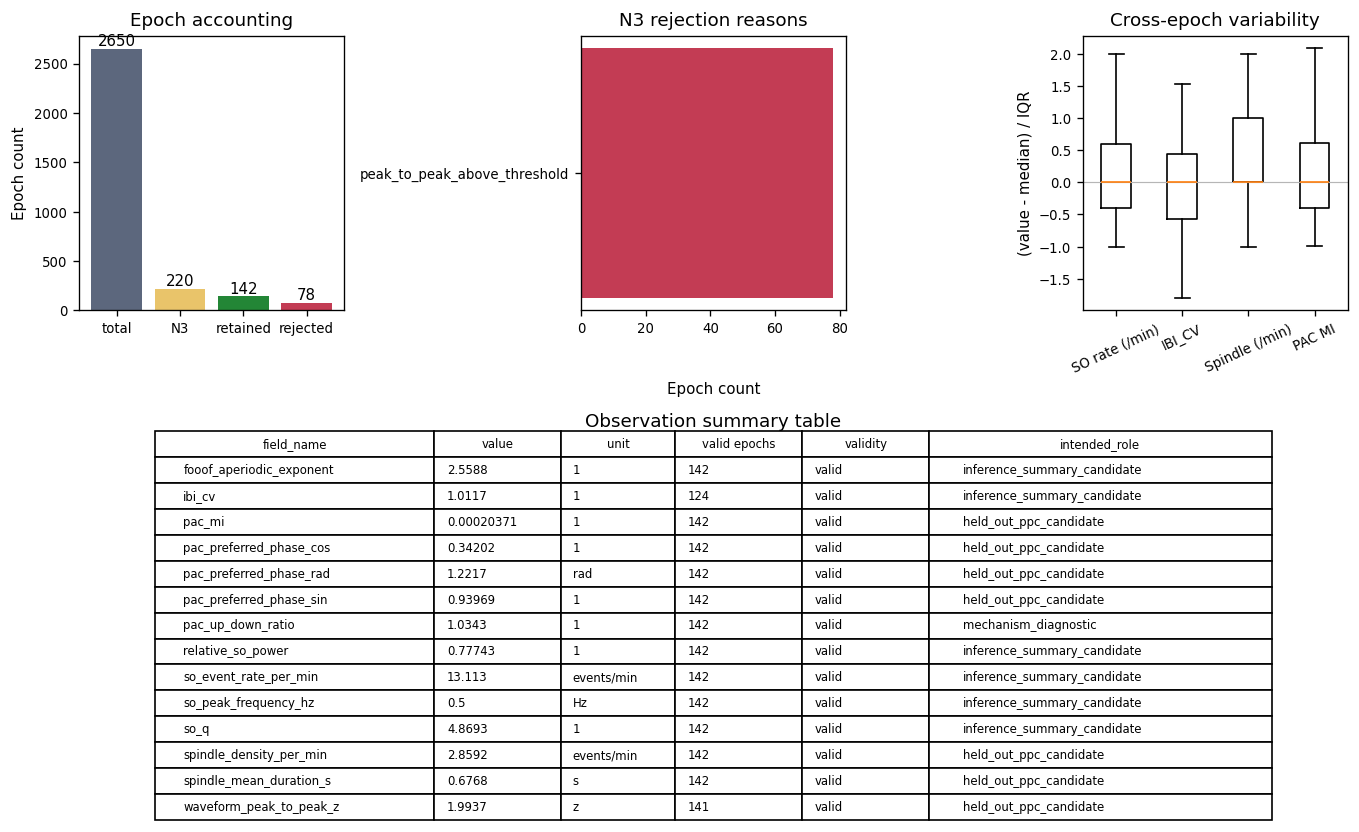

,field_name,value,unit,frequency_band,algorithm,aggregation_method,valid_epoch_count,validity_status,intended_role,warnings
0,fooof_aperiodic_exponent,2.558807,1,"[0.5, 20.0]",FOOOF fixed aperiodic fit,fit to arithmetic-mean Hann epoch PSD,142,valid,inference_summary_candidate,[]
1,ibi_cv,1.011715,1,"[0.2, 4.0]",coefficient of variation of within-epoch SO UP...,all within-epoch intervals pooled; no boundary...,124,valid,inference_summary_candidate,[]
2,pac_mi,0.000204,1,"[0.5, 1.5]",Tort normalized-KL modulation index,phase-bin amplitude pooled after per-epoch fil...,142,valid,held_out_ppc_candidate,[Single-channel observational PAC; retain as h...
3,pac_preferred_phase_cos,0.342020,1,"[0.5, 1.5]",cosine of maximum-amplitude PAC phase-bin center,from aggregate PAC phase-amplitude distribution,142,valid,held_out_ppc_candidate,[Single-channel observational PAC; retain as h...
4,pac_preferred_phase_rad,1.221730,rad,"[0.5, 1.5]",maximum-amplitude PAC phase-bin center,from aggregate PAC phase-amplitude distribution,142,valid,held_out_ppc_candidate,[Single-channel observational PAC; retain as h...
5,pac_preferred_phase_sin,0.939693,1,"[0.5, 1.5]",sine of maximum-amplitude PAC phase-bin center,from aggregate PAC phase-amplitude distribution,142,valid,held_out_ppc_candidate,[Single-channel observational PAC; retain as h...
6,pac_up_down_ratio,1.034337,1,"[0.5, 1.5]",spindle-envelope amplitude at UP phases / DOWN...,sample amplitudes pooled after per-epoch filte...,142,valid,mechanism_diagnostic,[Single-channel observational PAC; retain as h...
7,relative_so_power,0.777428,1,"[0.2, 1.5]",SO-band trapezoidal power / analysis-band power,ratio from aggregate Hann PSD,142,valid,inference_summary_candidate,[]
8,so_event_rate_per_min,13.112676,events/min,"[0.2, 4.0]",AASM-style DOWN-to-UP half-wave detector,events summed across epochs / retained N3 minutes,142,valid,inference_summary_candidate,[]
9,so_peak_frequency_hz,0.500000,Hz,"[0.2, 1.5]",maximum of aggregate Welch PSD in SO band,arithmetic mean across retained epoch PSDs,142,valid,inference_summary_candidate,[]


**Interpretation:** All 220 N3 epochs are accounted for as retained or rejected, with explicit rejection reasons. The table separates inference candidates from mechanism diagnostics and held-out PPC candidates instead of treating every observable as an inference target.

**Artifact:** `panels/obs_h_summary_qc.svg` and `.png`.

In [10]:
fig, obs_h_data = plot_obs_h_summary_qc(bundle)
display(fig)
panel_records["Obs-h"] = save_panel(
    fig, bundle, "Obs-h", obs_h_data, OUTPUT_ROOT, dpi=config.artifact_dpi
)
plt.close(fig)
summary_table = pd.DataFrame(bundle.summary_rows())
display(summary_table[[
    "field_name", "value", "unit", "frequency_band", "algorithm",
    "aggregation_method", "valid_epoch_count", "validity_status",
    "intended_role", "warnings",
]])
display(Markdown(
    f"**Interpretation:** All {obs_h_data['epoch_counts']['N3']} N3 epochs are accounted for as retained or rejected, with explicit rejection reasons. "
    "The table separates inference candidates from mechanism diagnostics and held-out PPC candidates instead of treating every observable as an inference target.\n\n"
    "**Artifact:** `panels/obs_h_summary_qc.svg` and `.png`."
))

## Observation-side field roles for the next contract stage

This is a classification aid, not a complete EEG-simulator `SummaryContractV1`. Real EEG cannot provide thalamic internal T8/T12 or V8a internal T13 values; those rows remain simulator-side mechanism descriptions only.

In [11]:
display(pd.DataFrame(metric_classification_rows()))

,class,metric,observation_status,note
0,A. inference-summary candidates,normalized_psd_0p5_20,computed in PSDResult.normalized_hann,scale invariant; Hann is primary
1,A. inference-summary candidates,so_peak_frequency_hz,computed,aggregate Hann PSD
2,A. inference-summary candidates,relative_so_power / so_q,computed,dimensionless SO summaries
3,A. inference-summary candidates,so_event_rate_per_min / ibi_cv,computed,within-epoch detector only
4,B. mechanism diagnostics,T8 / T12 thalamic spindle diagnostics,not observable from scalp EEG,simulator-side mechanism only
5,B. mechanism diagnostics,V8a internal T13,not observable from scalp EEG,simulator-side mechanism only
6,B. mechanism diagnostics,pac_up_down_ratio,computed,new name; T11_lag_ms is a legacy misnomer
7,C. held-out PPC candidates,spindle density / duration,computed,observable-channel 11-15 Hz RMS detector
8,C. held-out PPC candidates,PAC MI / preferred-phase sin and cos,computed,single-channel per-epoch filtering
9,C. held-out PPC candidates,SO waveform morphology,computed,trough-locked z-scored template


## Publication-safe artifact manifest

Only aggregate summaries, QC metadata, figure files, and panel metadata are written. Paths are relative inside the manifest; complete EEG arrays, EDF copies, subject-level sample traces, and machine absolute paths are excluded. The ignored `outputs/` policy is preserved.

In [12]:
assert set(panel_records) == {f"Obs-{letter}" for letter in "abcdefgh"}
artifact_paths = write_observation_artifacts(
    bundle, [panel_records[key] for key in sorted(panel_records)], OUTPUT_ROOT
)
display(pd.DataFrame(panel_records.values())[[
    "panel_id", "title", "input_epoch_count", "valid_epoch_count", "artifacts", "warnings"
]])
print("Publication-safe outputs:")
for name, path in artifact_paths.items():
    print(f" - {name}: {path.relative_to(ROOT).as_posix()}")
print("\nObservation overview was intentionally omitted: independent panels remain readable and authoritative.")

,panel_id,title,input_epoch_count,valid_epoch_count,artifacts,warnings
0,Obs-a,Recording context and N3 selection,220,142,"[panels/obs_a_recording_context.svg, panels/ob...",[]
1,Obs-b,Representative 30-second N3 EEG,220,4,"[panels/obs_b_representative_eeg.svg, panels/o...",[]
2,Obs-c,Epoch-level and aggregate PSD,220,142,"[panels/obs_c_psd.svg, panels/obs_c_psd.png]",[]
3,Obs-d,Slow-oscillation waveform morphology,220,141,"[panels/obs_d_so_morphology.svg, panels/obs_d_...",[]
4,Obs-e,SO timing and regularity,220,124,"[panels/obs_e_so_regularity.svg, panels/obs_e_...",[]
5,Obs-f,Observable spindle activity,220,142,"[panels/obs_f_spindle_activity.svg, panels/obs...",[held_out_ppc_candidate; detector is not cross...
6,Obs-g,SO-spindle coupling / PAC,220,142,"[panels/obs_g_pac.svg, panels/obs_g_pac.png]",[single-channel observational PAC; held_out_pp...
7,Obs-h,QC and Observation summary table,220,142,"[panels/obs_h_summary_qc.svg, panels/obs_h_sum...",[]


Publication-safe outputs:
 - observation_summary: outputs/observation_sc4001/observation_summary.csv
 - qc_summary: outputs/observation_sc4001/qc_summary.json
 - panel_manifest: outputs/observation_sc4001/panel_manifest.json

Observation overview was intentionally omitted: independent panels remain readable and authoritative.
